# 07 · Bivariate analysis

Six simulated paired samples hold the marginal families fixed while changing the copula.
Restart Kernel and Run All rebuilds and estimates each model from raw observations.
API reference: `BivariateAnalysisParameterRecoveryTests.cs` constructs fitted Normal
marginals, `BivariateDistribution`, and a Bayesian `BivariateAnalysis`.

In [2]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from time import perf_counter
import math
import pandas as pd
from IPython.display import display
from bestfit_examples.runtime import load_bestfit
from bestfit_examples.raw import load_raw
from bestfit_examples.fresh import plot_context, plots, show, record_run
runtime = load_bestfit()
print(runtime)
from System import Array, Double, DateTime
from Numerics.Distributions import UnivariateDistributionType, Uniform
from Numerics.Distributions.Copulas import CopulaType
from RMC.BestFit.Models import DataFrame, ExactData, ExactSeries, UnivariateDistribution, BivariateDistribution
from RMC.BestFit.Analyses import UnivariateAnalysis, BivariateAnalysis
from RMC.BestFit.Estimation import BayesianAnalysis

{'schemaVersion': 1, 'sourceCommit': 'db5807d6e3a85606797cda79542f2d51a80a57a6', 'numericsVersion': '2.2.0.0', 'bestFitVersion': '2.0.0.0', 'targetFramework': '.NETCoreApp,Version=v10.0', 'fileHashes': {'RMC.BestFit.dll': '8714d7e4e9d738e99e45c36d5581ce759e8fd535361b7a141d9647a9a5eac8dd', 'Numerics.dll': '364d2296a6024643a8bf0f60d1eaa8f5be5511563dea0b5d572074e45c27ea48'}}


## Observed pairs and model families

Every copula case has its own 100 matched synthetic X/Y observations. The stored rows
are observations, not saved distribution objects or posterior draws. A shared index
identifies a pair; sorting X and Y separately would destroy dependence.

In [3]:
raw = load_raw("bivariate-distribution-examples")
case_specs = [
    ("AMH Copula", "AMH", CopulaType.AliMikhailHaq),
    ("Clayton Copula", "Clayton", CopulaType.Clayton),
    ("Frank Copula", "Frank", CopulaType.Frank),
    ("Gumbel Copula", "Gumbel", CopulaType.Gumbel),
    ("Joe Copula", "Joe", CopulaType.Joe),
    ("Normal Copula", "Normal", CopulaType.Normal),
]
display(pd.DataFrame([{"Case": name, "X records": len(raw["inputs"][f"{prefix} - X Data"]["series"]["ExactSeries"]),
                       "Y records": len(raw["inputs"][f"{prefix} - Y Data"]["series"]["ExactSeries"])}
                      for name, prefix, _ in case_specs]))
print(raw["source"])

,Case,X records,Y records
0,AMH Copula,100,100
1,Clayton Copula,100,100
2,Frank Copula,100,100
3,Gumbel Copula,100,100
4,Joe Copula,100,100
5,Normal Copula,100,100


{'bytes': 15269888, 'relative_path': 'examples/5-bivariate-distribution-analysis/1-bivariate-distributions/bivariate-distribution-examples.bestfit', 'repository_commit': '3fa55a0f75bbd583e2fb7fce42180faa376f007c', 'sha256': '56f9408158fea1b2a75e5fb220cde52d4c2e8a5abbc913835026684b2cec12ec'}


## Construct and estimate the two Normal marginals

Each input becomes a BestFit `DataFrame`, with its own indexed `ExactData` values.
The saved app design uses Jeffreys' rule for scale and a 90% credible interval.
The AMH X row has its flat-prior switch off, with explicit Uniform priors on mean
[-1000,1000] and scale [machine epsilon,1000]; preserve that exception.
These marginal fits supply point distributions to inference from margins.

In [4]:
frames, marginal_models, marginal_analyses = {}, {}, {}
for name, prefix, _ in case_specs:
    for axis in ("X", "Y"):
        input_name = f"{prefix} - {axis} Data"
        observed = raw["inputs"][input_name]
        frame = DataFrame()
        frame.ExactSeries = ExactSeries()
        for row in observed["series"]["ExactSeries"]:
            point = ExactData(DateTime.Parse(row["DateTime"]), float(row["Value"]))
            point.Index = int(row["Index"])
            point.IsLowOutlier = row.get("IsLowOutlier", "False") == "True"
            frame.ExactSeries.Add(point)
        frame.PlottingParameter = float(observed["attributes"]["PlottingParameter"])
        assert frame.Lambda == 1.0
        frame.CalculatePlottingPositions()
        frames[input_name] = frame
        model = UnivariateDistribution(frame, UnivariateDistributionType.Normal)
        model.UseJeffreysRuleForScale = True
        model.UseDefaultFlatPriors = input_name != "AMH - X Data"
        if input_name == "AMH - X Data":
            model.Parameters[0].LowerBound = -1000.0
            model.Parameters[0].UpperBound = 1000.0
            model.Parameters[0].PriorDistribution = Uniform(-1000.0, 1000.0)
            model.Parameters[1].LowerBound = 1.11022302462516e-16
            model.Parameters[1].UpperBound = 1000.0
            model.Parameters[1].PriorDistribution = Uniform(1.11022302462516e-16, 1000.0)
        marginal_models[input_name] = model
        analysis = UnivariateAnalysis(model)
        analysis.Name = f"{prefix} - Marginal {axis}"
        bayes = analysis.BayesianAnalysis
        bayes.UseSimulationDefaults = True
        bayes.Type = BayesianAnalysis.SamplerType.DEMCzs
        bayes.NumberOfChains = 6 if input_name == "AMH - X Data" else 4
        bayes.ThinningInterval = 30 if input_name == "AMH - X Data" else 20
        bayes.WarmupIterations = 1750
        bayes.Iterations = 3500
        bayes.PRNGSeed = 12345
        bayes.UseAdvancedSimulationDefaults = True
        bayes.InitialIterations = 300 if input_name == "AMH - X Data" else 200
        bayes.Jump = .971630931303994 if input_name == "AMH - X Data" else 1.19
        bayes.CredibleIntervalWidth = .9
        bayes.OutputLength = 10000
        bayes.PointEstimator = BayesianAnalysis.PointEstimateType.PosteriorMean
        started = perf_counter()
        analysis.RunAsync(None).GetAwaiter().GetResult()
        marginal_analyses[input_name] = analysis
        record_run(analysis.Name, analysis, perf_counter() - started, raw=raw, model=model)

AMH - Marginal X: completed in 1.56 s. Execution alone does not establish convergence or scientific acceptance.


AMH - Marginal Y: completed in 0.89 s. Execution alone does not establish convergence or scientific acceptance.


Clayton - Marginal X: completed in 0.74 s. Execution alone does not establish convergence or scientific acceptance.


Clayton - Marginal Y: completed in 0.51 s. Execution alone does not establish convergence or scientific acceptance.


Frank - Marginal X: completed in 0.41 s. Execution alone does not establish convergence or scientific acceptance.


...

Gumbel - Marginal Y: completed in 0.35 s. Execution alone does not establish convergence or scientific acceptance.


Joe - Marginal X: completed in 0.36 s. Execution alone does not establish convergence or scientific acceptance.


Joe - Marginal Y: completed in 0.34 s. Execution alone does not establish convergence or scientific acceptance.


Normal - Marginal X: completed in 0.34 s. Execution alone does not establish convergence or scientific acceptance.


Normal - Marginal Y: completed in 0.36 s. Execution alone does not establish convergence or scientific acceptance.


## Fit the copula, conditional on the fitted marginals

`InferenceFromMargins` uses the fitted marginal CDFs. The bivariate chain samples
copula parameters; its posterior bands do not include marginal parameter uncertainty.
Each construction and execution remains visible here.

In [5]:
analyses, models, timings = {}, {}, {}
for name, prefix, copula_type in case_specs:
    marginal_x = marginal_models[f"{prefix} - X Data"]
    marginal_y = marginal_models[f"{prefix} - Y Data"]
    model = BivariateDistribution(marginal_x, marginal_y, copula_type)
    assert str(model.CopulaEstimationMethod) == "InferenceFromMargins"
    model.UseDefaultFlatPriors = True
    analysis = BivariateAnalysis(model)
    analysis.Name = name
    bayes = analysis.BayesianAnalysis
    bayes.UseSimulationDefaults = True
    bayes.Type = BayesianAnalysis.SamplerType.DEMCzs
    bayes.NumberOfChains = 4
    bayes.ThinningInterval = 10
    bayes.WarmupIterations = 1750
    bayes.Iterations = 3500
    bayes.PRNGSeed = 12345
    bayes.UseAdvancedSimulationDefaults = True
    bayes.InitialIterations = 100
    bayes.Jump = 1.6829141392239828
    bayes.CredibleIntervalWidth = .9
    bayes.OutputLength = 10000
    bayes.PointEstimator = BayesianAnalysis.PointEstimateType.PosteriorMean
    started = perf_counter()
    analysis.RunAsync(None).GetAwaiter().GetResult()
    timings[name] = perf_counter() - started
    analyses[name], models[name] = analysis, model
    record_run(name, analysis, timings[name], raw=raw, model=model)

AMH Copula: completed in 1.61 s. Execution alone does not establish convergence or scientific acceptance.


Clayton Copula: completed in 3.58 s. Execution alone does not establish convergence or scientific acceptance.


Frank Copula: completed in 2.01 s. Execution alone does not establish convergence or scientific acceptance.


Gumbel Copula: completed in 4.93 s. Execution alone does not establish convergence or scientific acceptance.


Joe Copula: completed in 5.81 s. Execution alone does not establish convergence or scientific acceptance.


Normal Copula: completed in 2.09 s. Execution alone does not establish convergence or scientific acceptance.


## Read the fresh parameter summaries and visualize dependence

The six datasets are separately simulated; a score across rows is not a controlled
model comparison. Inspect paired values alongside marginal-probability coordinates.
The density contour in CDF coordinates is natural-log **joint** density evaluated
at values mapped from marginal probabilities. Joint exceedance is a probability,
not a response-frequency curve.

,Case,Copula,Posterior mean,R-hat,ESS,X records,Y records
0,AMH Copula,AliMikhailHaq,0.812590,0.999901,7475.173797,100,100
1,Clayton Copula,Clayton,1.601875,1.000150,9485.024268,100,100
2,Frank Copula,Frank,8.958372,1.000321,9455.116176,100,100
3,Gumbel Copula,Gumbel,1.922324,1.000493,9676.401880,100,100
4,Joe Copula,Joe,3.001184,0.999913,9765.978097,100,100
5,Normal Copula,Normal,0.785389,1.000295,9249.445343,100,100


,Fitted rho,"BestFit C(0.5,0.5)","Analytic C(0.5,0.5)",Absolute error
0,0.785389,0.393768,0.393768,0.0


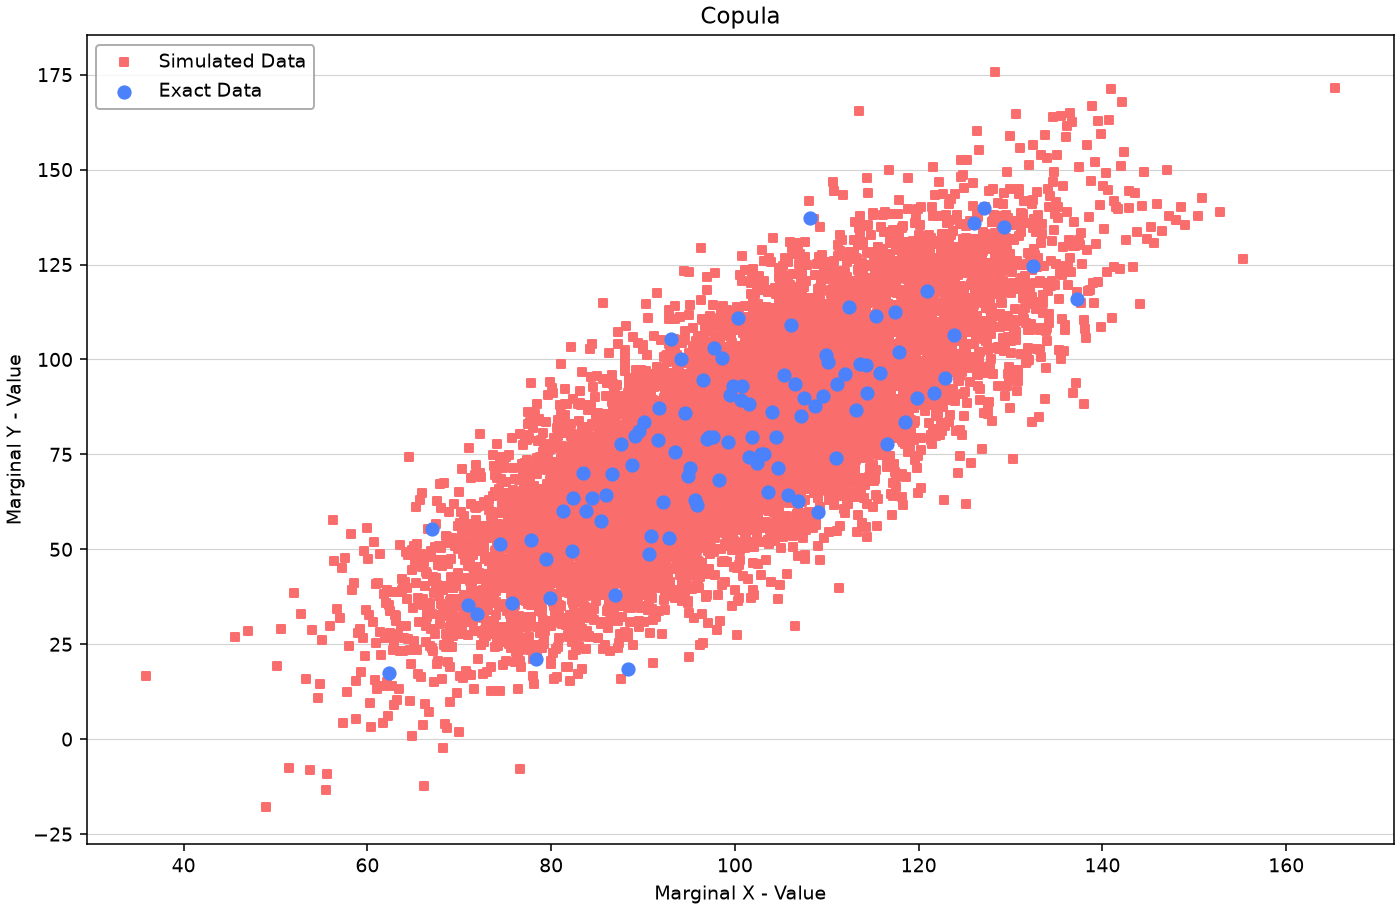

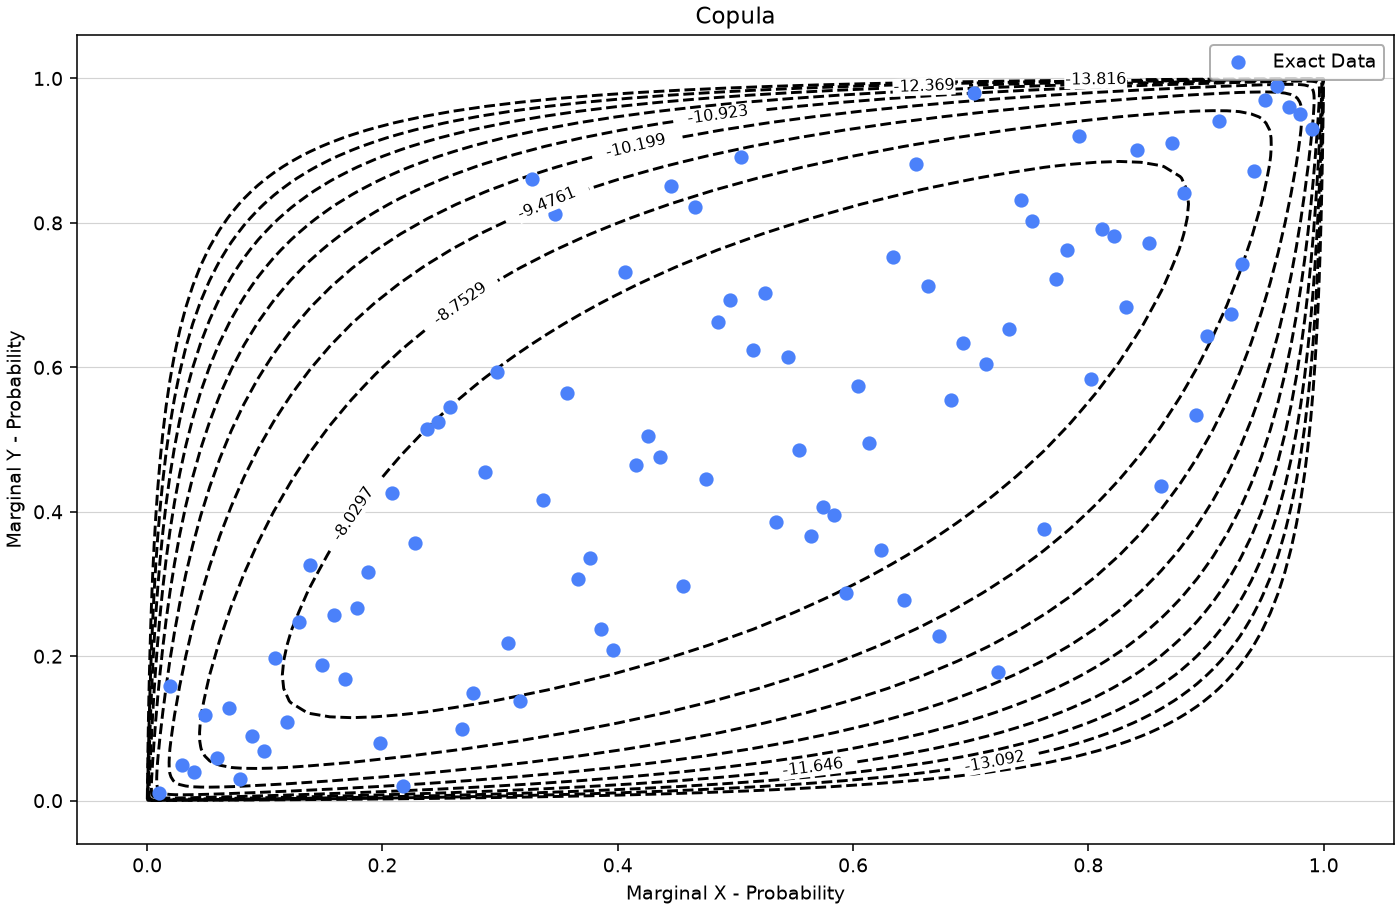

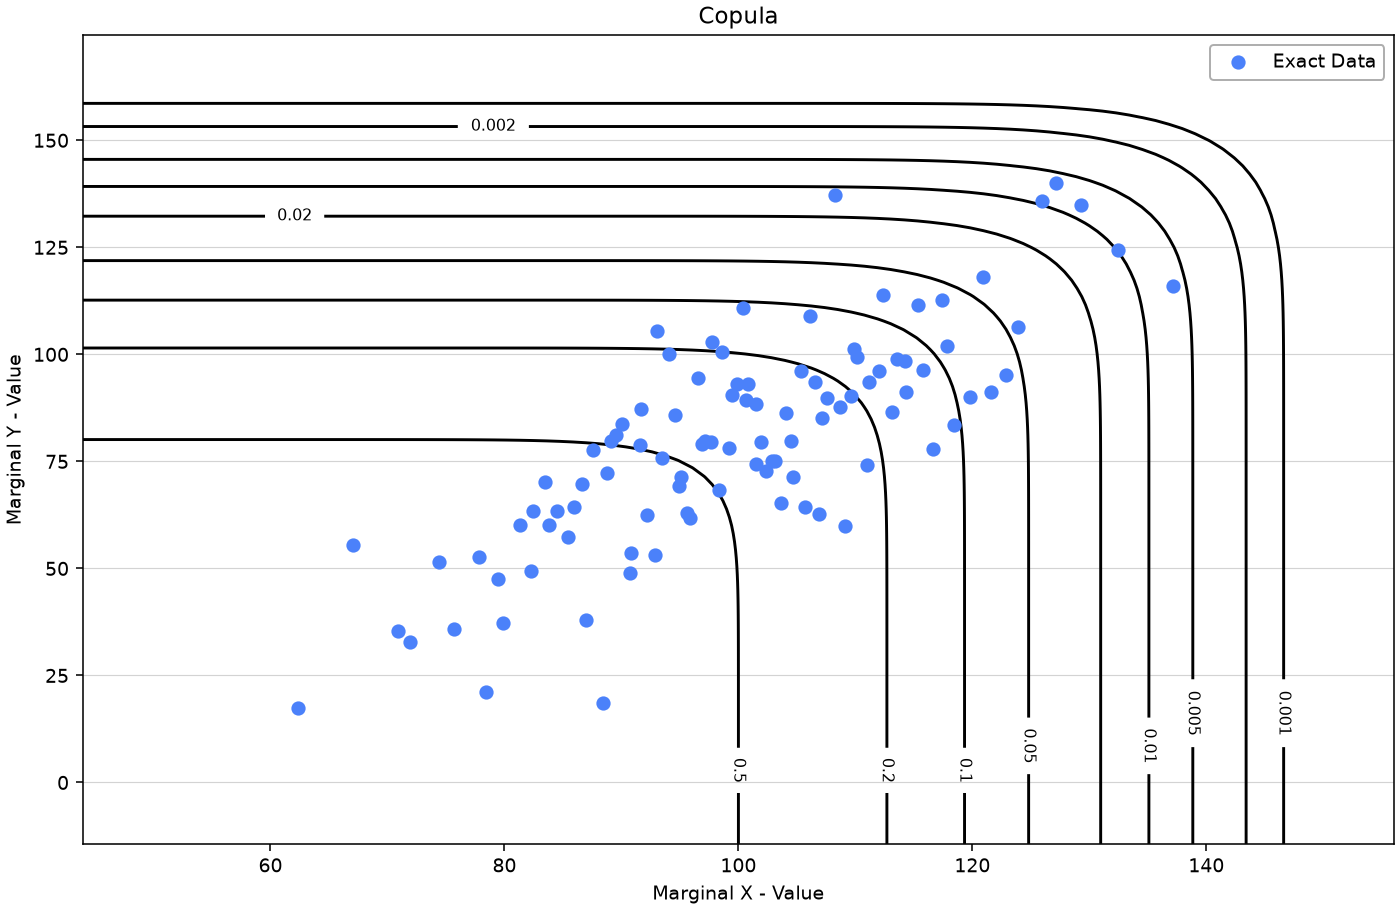

In [6]:
rows = []
for name, prefix, _ in case_specs:
    result = analyses[name].BayesianAnalysis.Results
    assert analyses[name].IsEstimated and result is not None
    summary = result.ParameterResults[0].SummaryStatistics
    rows.append({"Case": name, "Copula": str(models[name].CopulaType),
                 "Posterior mean": float(result.PosteriorMean.Values[0]),
                 "R-hat": float(summary.Rhat), "ESS": float(summary.ESS),
                 "X records": frames[f"{prefix} - X Data"].ExactSeries.Count,
                 "Y records": frames[f"{prefix} - Y Data"].ExactSeries.Count})
display(pd.DataFrame(rows))
# Independent Gaussian orthant identity at the freshly fitted copula rho.
normal_rho = float(analyses["Normal Copula"].BayesianAnalysis.Results.PosteriorMean.Values[0])
normal_copula = models["Normal Copula"].Copula.Clone()
normal_copula.SetCopulaParameters(Array[Double]([normal_rho]))
computed_quadrant = float(normal_copula.CDF(.5, .5))
analytic_quadrant = .25 + math.asin(normal_rho)/(2*math.pi)
assert abs(computed_quadrant - analytic_quadrant) < 1e-8
display(pd.DataFrame([{"Fitted rho": normal_rho, "BestFit C(0.5,0.5)": computed_quadrant,
                       "Analytic C(0.5,0.5)": analytic_quadrant,
                       "Absolute error": abs(computed_quadrant - analytic_quadrant)}]))
figures = {}
for name, prefix, _ in case_specs:
    context = plot_context(analyses[name], models[name], name=name, raw=raw,
        dependencies={"MarginalX": {"input_row": raw["inputs"][f"{prefix} - X Data"]["metadata"]},
                      "MarginalY": {"input_row": raw["inputs"][f"{prefix} - Y Data"]["metadata"]}})
    figures[name] = plots(context)
show(figures["Normal Copula"]["scatter_values"])
show(figures["Normal Copula"]["density_cdf"])
show(figures["Normal Copula"]["joint_exceedance_values"])

**Adapt this example:** replace matched X/Y observations, choose marginal distributions
and a copula, run the marginal and bivariate analyses, then inspect posterior diagnostics
before drawing conclusions about joint tails. Notebook 08 adds an engineered response grid.